In [1]:
#1. Conjunto de datos

from tensorflow.keras import datasets

fashion_minst = datasets.fashion_mnist



In [2]:
dir(fashion_minst)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'load_data']

In [3]:
(X_train, y_train), (X_test, y_test) = fashion_minst.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
#2. visualización de los datos

#Os dejo pensar... mirar el ejemplo del otro día
#Dibujarme las 8 primeras...
#Jugar a ver que tienen...

#Como son los datos
X_train.shape

(60000, 28, 28)

In [5]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(20,5))

<Figure size 2000x500 with 0 Axes>

<Figure size 2000x500 with 0 Axes>

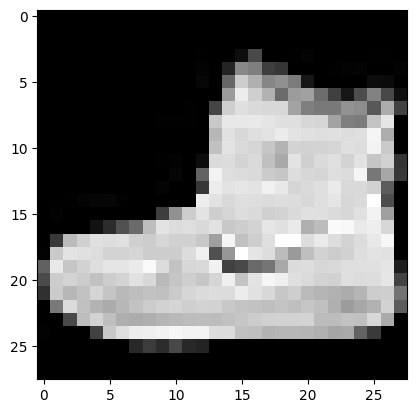

In [6]:
plt.imshow(X_train[0], cmap='gray')
plt.show()

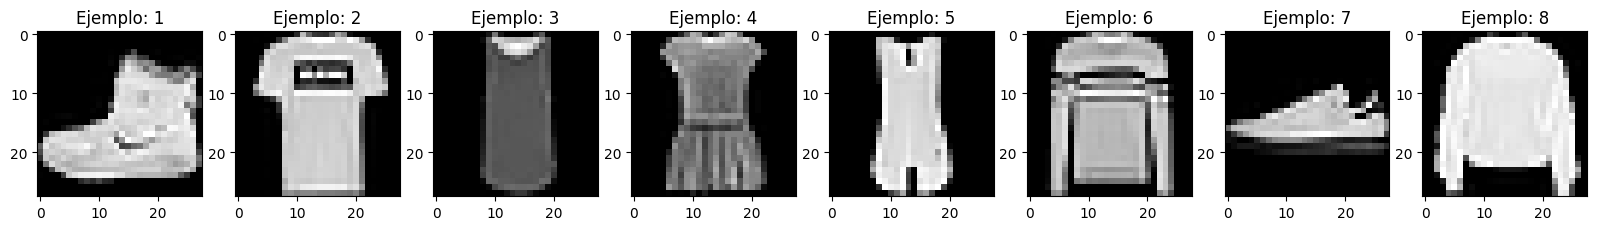

In [7]:
plt.figure(figsize=(20,5))
for index, img in zip(range(1, 9), X_train[:8]):
    plt.subplot(1, 8, index)
    plt.imshow(img, cmap=plt.cm.gray)
    plt.title('Ejemplo: ' + str(index))
plt.show()

In [8]:
#3. Transformar el conjunto de datos

X_train_prep = X_train.reshape(60000, 28*28)
X_test_prep = X_test.reshape(10000, 28*28)

In [9]:
#Normalizar
from sklearn.preprocessing import Normalizer
transform = Normalizer()

In [10]:
X_train_prep = transform.fit_transform(X_train_prep)
X_test_prep = transform.transform(X_test_prep)

In [11]:
from tensorflow.keras.utils import to_categorical
y_train_prep = to_categorical(y_train)
y_test_prep = to_categorical(y_test)

In [12]:
y_train_prep[1]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [13]:
y_train[0]

np.uint8(9)

In [14]:
#Construcción del modelo

from tensorflow.keras import models
from tensorflow.keras import layers

network = models.Sequential()

In [15]:
network.add(layers.Dense(256, activation='relu', input_shape=(28*28,)))
network.add(layers.Dense(128, activation='relu'))
network.add(layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
network.compile(optimizer='adam', loss='categorical_crossentropy',
                metrics=['accuracy'])

In [24]:
history = network.fit(X_train_prep,
            y_train_prep,
            epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9208 - loss: 0.2105
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9212 - loss: 0.2095
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9269 - loss: 0.1967
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9278 - loss: 0.1907
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9319 - loss: 0.1827
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9350 - loss: 0.1736
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9360 - loss: 0.1710
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9375 - loss: 0.1666
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9401 - loss: 0.1580
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9442 - loss: 0.1482


In [25]:
history.history

{'accuracy': [0.9192666411399841,
  0.9208999872207642,
  0.9245666861534119,
  0.9273666739463806,
  0.9298666715621948,
  0.9329500198364258,
  0.935366690158844,
  0.9363999962806702,
  0.9390333294868469,
  0.941516637802124],
 'loss': [0.21537534892559052,
  0.2102144956588745,
  0.20001138746738434,
  0.1918037086725235,
  0.18611367046833038,
  0.17739172279834747,
  0.17110426723957062,
  0.16594740748405457,
  0.16090738773345947,
  0.15327034890651703]}

In [26]:
#Jugamos a ver como predice???

y_pred = network.predict(X_test_prep) # -> X_test_prep tiene las imagenes que no ha visto

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [27]:
y_pred.shape

(10000, 10)

In [28]:
np.argmax(y_pred[0])

np.int64(9)

In [29]:
y_test_prep[0] # -> Aqui tenemos el zapatito por el ultimo, según la posición del 1 es un objeto u otro

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])